# BusinessPulse AI

## Customer Churn Intelligence Platform

### Business Problem

Customer churn is one of the biggest challenges for subscription-based businesses. Losing existing customers directly impacts revenue, customer lifetime value, and long-term growth.

### Project Objective

The objective of this project is to develop an AI-powered platform capable of:

- Predicting customer churn
- Understanding the reasons behind churn
- Estimating business impact
- Recommending retention strategies
- Providing business insights through interactive dashboards

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("../data/customer_churn.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [3]:
# ============================================
# Preview Dataset
# ============================================

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ============================================
# Dataset Shape
# ============================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 7043
Number of Columns : 21


In [5]:
# ============================================
# Column Names
# ============================================

df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

## Dataset Overview

In this section, we inspect the structure of the dataset, identify data types, and check for missing values before performing any preprocessing or analysis.

In [6]:
# ============================================
# Dataset Information
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# ============================================
# Numerical Summary
# ============================================

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# ============================================
# Categorical Summary
# ============================================

df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Data Quality Assessment

Before performing exploratory data analysis, we assess the overall quality of the dataset by checking for missing values, duplicate records, and inconsistencies in data types.

In [9]:
# ============================================
# Missing Values
# ============================================

missing_values = df.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# ============================================
# Total Missing Values
# ============================================

missing_values.sum()

np.int64(0)

In [11]:
# ============================================
# Duplicate Records
# ============================================

df.duplicated().sum()

np.int64(0)

In [12]:
# ============================================
# Dataset Shape
# ============================================

print(df.shape)

(7043, 21)


In [13]:
# ============================================
# Blank values in TotalCharges
# ============================================

(df["TotalCharges"] == " ").sum()

np.int64(11)

## Observations

- No missing values were detected using the standard missing value check.
- No duplicate records were found.
- The dataset contains 7,043 customer records and 21 features.
- The `TotalCharges` column contains blank string values that require cleaning before model development.

# Data Cleaning

In this section, hidden missing values are identified and cleaned. The dataset is prepared for further exploratory data analysis and machine learning by correcting data types and handling incomplete records.

In [14]:
# ============================================
# Replace Blank Values with NaN
# ============================================

import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [15]:
# ============================================
# Missing Values After Replacement
# ============================================

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
# ============================================
# Convert TotalCharges to Numeric
# ============================================

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [17]:
# ============================================
# Verify Updated Data Types
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
# ============================================
# Remove Missing Records
# ============================================

df = df.dropna()

In [19]:
# ============================================
# Verify Dataset Shape
# ============================================

print(df.shape)

(7032, 21)


In [20]:
# ============================================
# Final Missing Value Check
# ============================================

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
# ============================================
# Verify Duplicate Records
# ============================================

df.duplicated().sum()

np.int64(0)

## Data Cleaning Summary

The data cleaning process successfully prepared the dataset for analysis.

Key preprocessing steps performed:

- Replaced blank strings in the `TotalCharges` column with missing values (`NaN`).
- Converted `TotalCharges` from an object data type to a numeric format.
- Removed 11 incomplete customer records containing missing values.
- Verified that the cleaned dataset contains no missing values or duplicate records.
- The final cleaned dataset consists of **7,032 customer records** and **21 features**, making it suitable for exploratory data analysis and machine learning.

# Exploratory Data Analysis (EDA)

This section explores customer behavior through visualizations and statistical analysis.
The objective is to identify important patterns, understand customer churn characteristics,
and generate business insights that will support machine learning model development.

In [22]:
# ==============================================
# Import Visualization Libraries
# ==============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_palette("Set2")

## 1. Target Variable Analysis

The target variable is explored to understand the distribution of customers who stayed and customers who churned.
This helps identify class imbalance before model training.

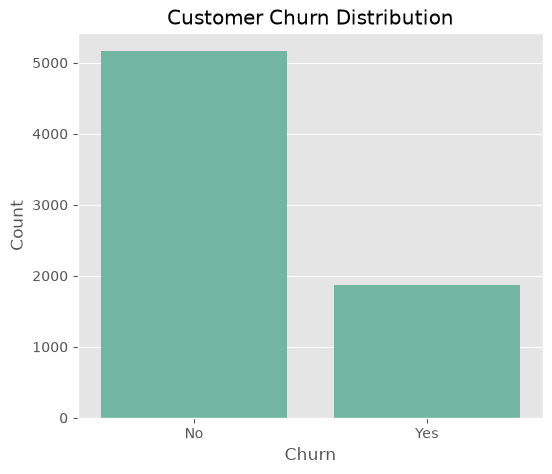

In [23]:
# ==============================================
# Churn Distribution
# ==============================================

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Count")

plt.show()

In [24]:
# ==============================================
# Churn Percentage
# ==============================================

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### Observation

- Most customers did not churn.
- Around one-fourth of customers left the company.
- The dataset is moderately imbalanced, which should be considered during model training.

## 2. Numerical Feature Analysis

The numerical variables are analyzed to understand their distributions,
identify skewness, detect outliers, and observe customer spending patterns.

In [25]:
# ==============================================
# Numerical Columns
# ==============================================

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


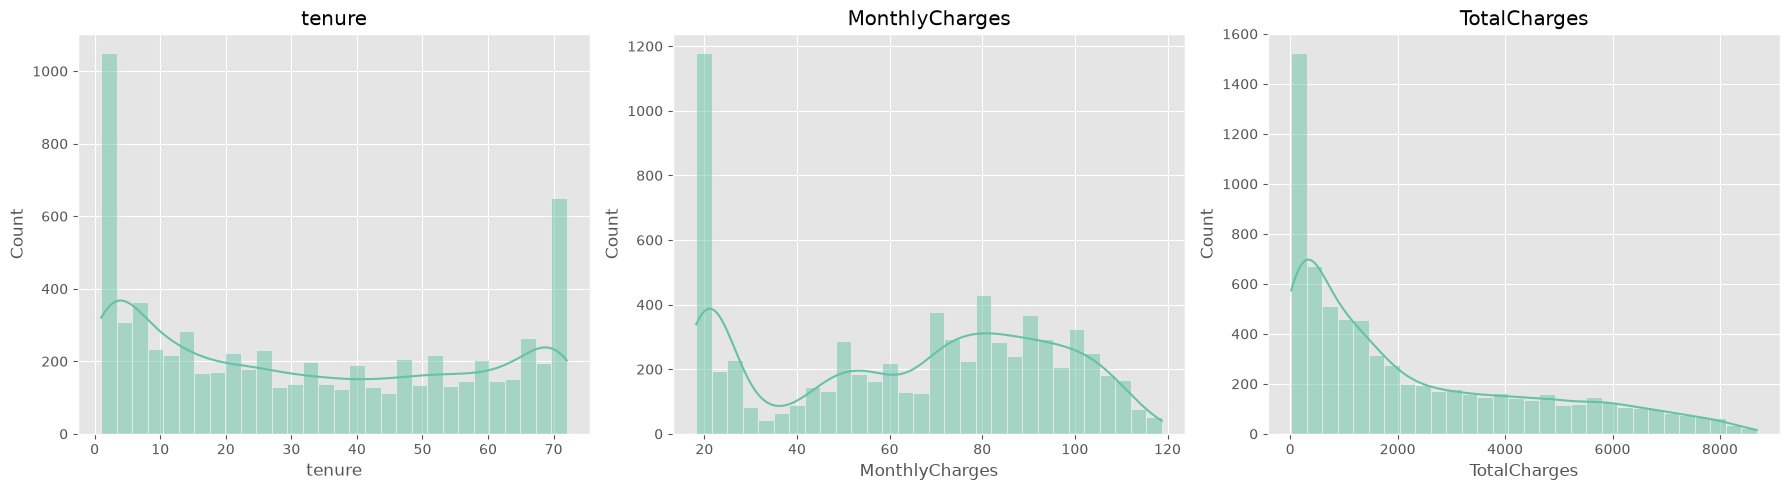

In [26]:
# ==============================================
# Histograms
# ==============================================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.show()

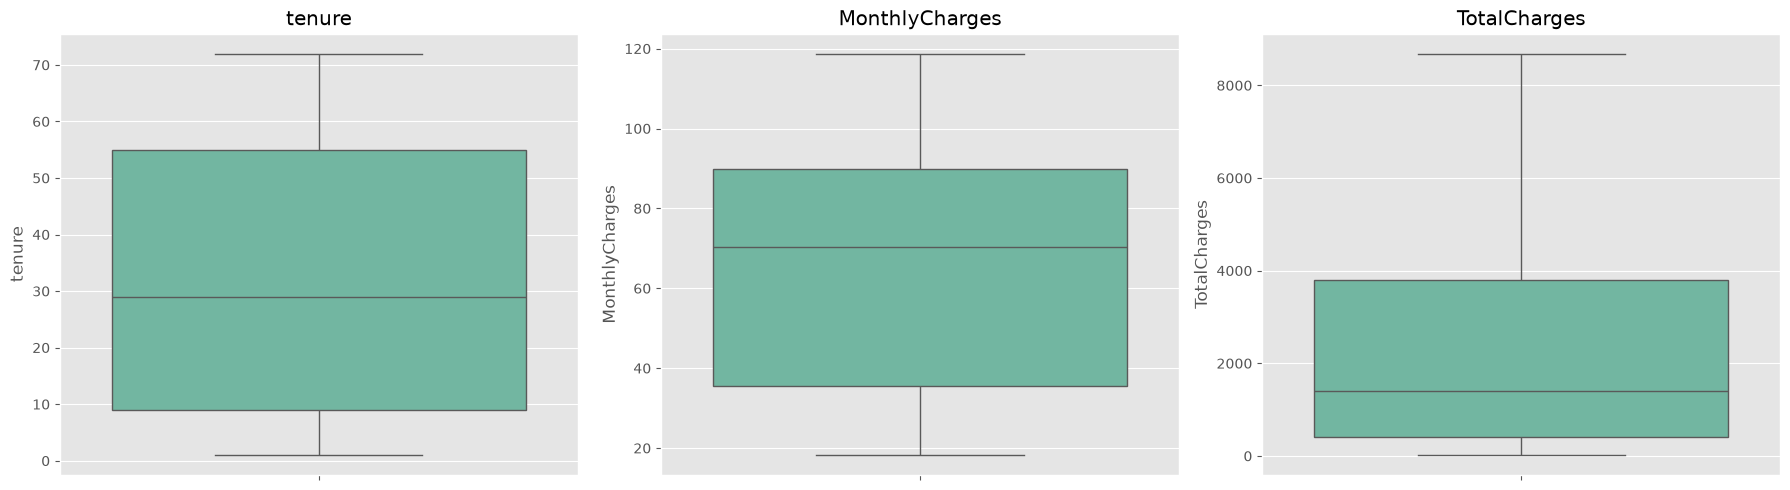

In [27]:
# ==============================================
# Boxplots
# ==============================================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numerical_columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.show()

### Observation

- Customer tenure ranges from new customers to long-term subscribers.
- Monthly charges are fairly well distributed with moderate variation.
- Total charges show a right-skewed distribution because long-term customers accumulate larger bills.
- A few outliers are present in TotalCharges, which is expected for long-tenure customers.

## 3. Numerical Features vs Churn

This analysis compares numerical variables across churn categories to identify
whether customer tenure, monthly charges, and total charges influence customer
retention.

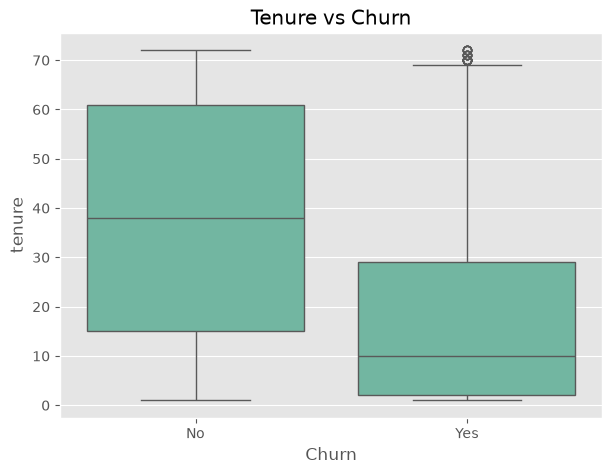

In [28]:
# ==============================================
# Tenure vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure vs Churn")

plt.show()

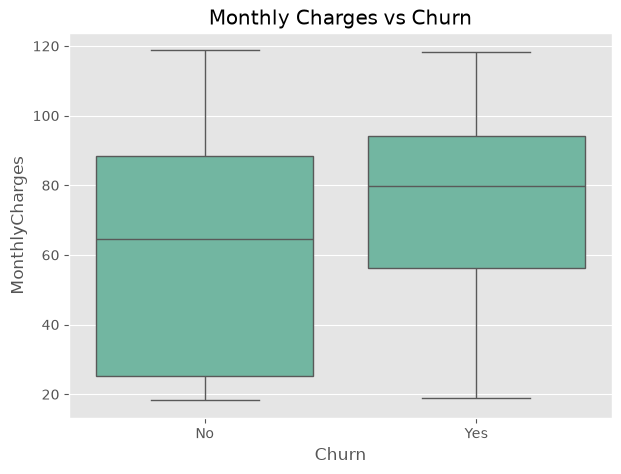

In [29]:
# ==============================================
# Monthly Charges vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")

plt.show()

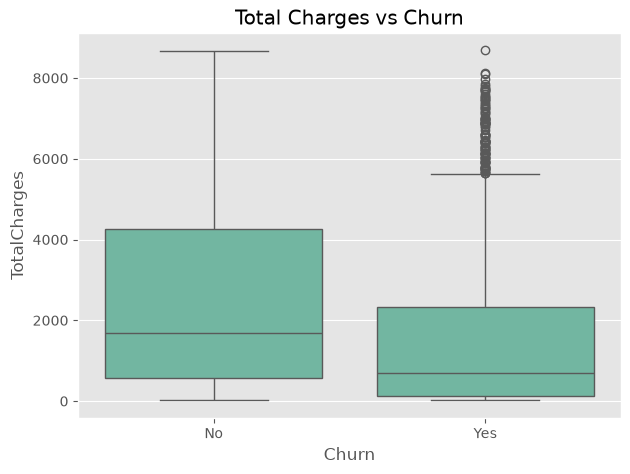

In [30]:
# ==============================================
# Total Charges vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges vs Churn")

plt.show()

### Observation

- Customers who churn generally have shorter subscription periods.
- Customers with higher monthly charges tend to churn more frequently.
- Long-term customers usually accumulate higher total charges and are less likely to churn.
- Customer tenure appears to be one of the strongest indicators of churn.

## 4. Categorical Feature Analysis

Categorical variables are analyzed to understand how customer characteristics,
subscription plans, and payment preferences influence customer churn.

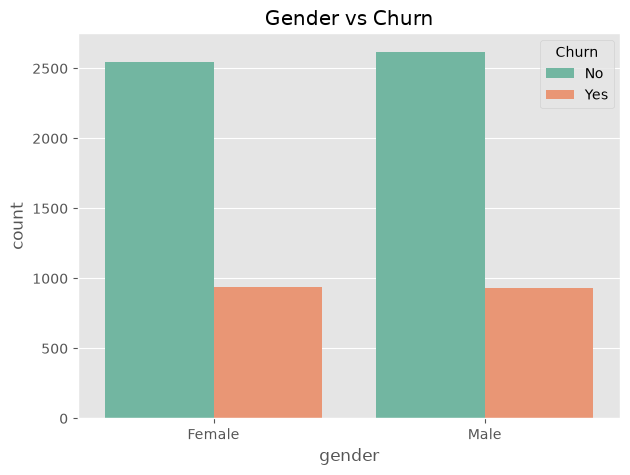

In [31]:
# ==============================================
# Gender vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Gender vs Churn")

plt.show()

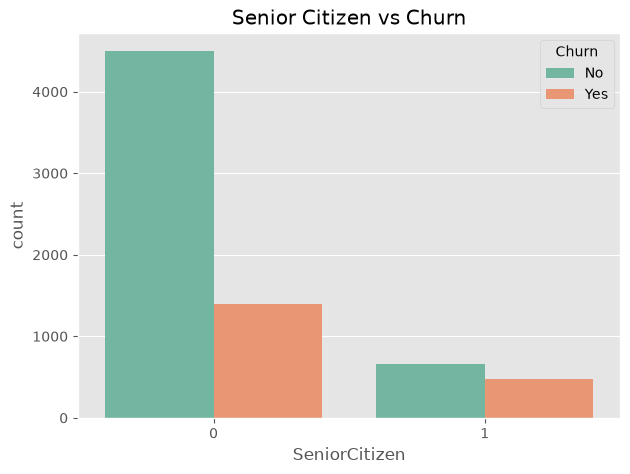

In [32]:
# ==============================================
# Senior Citizen vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Senior Citizen vs Churn")

plt.show()

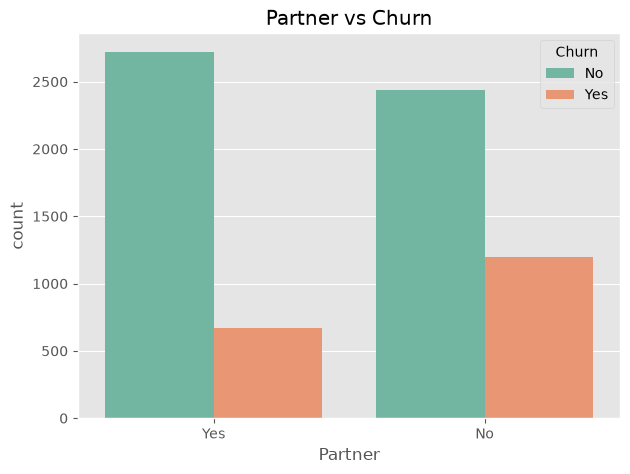

In [33]:
# ==============================================
# Partner vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Partner vs Churn")

plt.show()

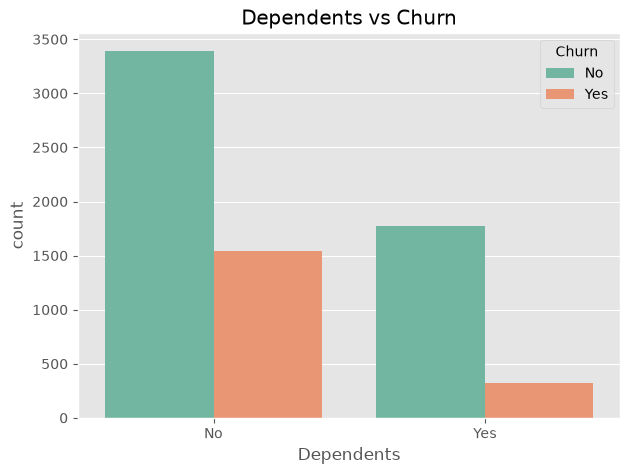

In [34]:
# ==============================================
# Dependents vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Dependents", hue="Churn")

plt.title("Dependents vs Churn")

plt.show()

### Observation

- Customer churn is similar across male and female customers.
- Senior citizens show a noticeably higher churn rate than non-senior customers.
- Customers without partners are more likely to churn.
- Customers without dependents also exhibit higher churn behavior.

## 5. Service-Related Feature Analysis

This section examines how different telecom services influence customer churn.
These services directly affect customer satisfaction and retention.

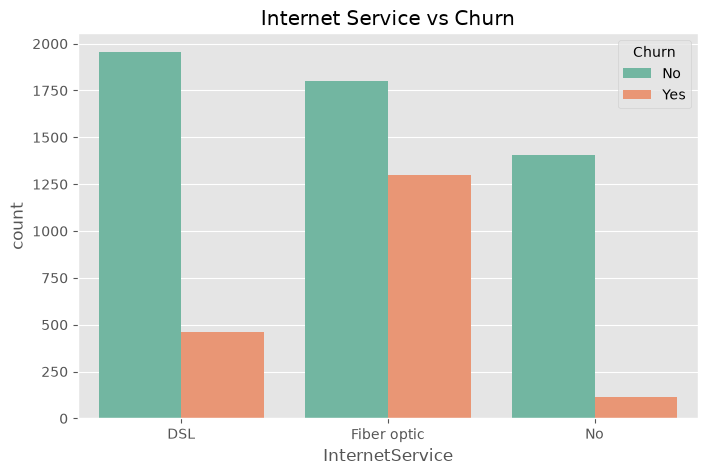

In [35]:
# ==============================================
# Internet Service vs Churn
# ==============================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Churn")

plt.show()

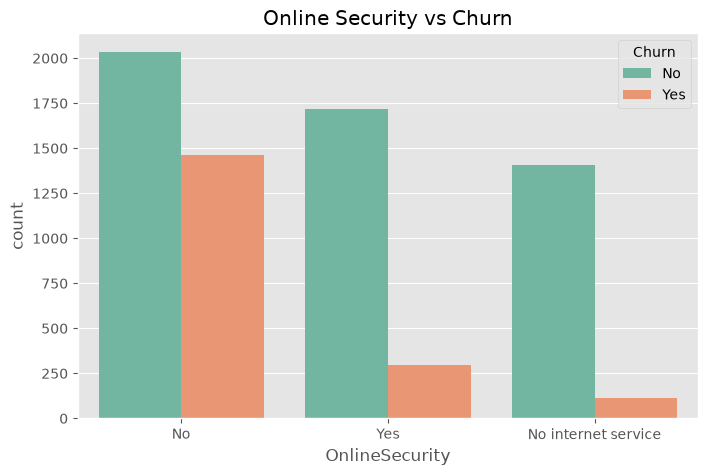

In [36]:
# ==============================================
# Online Security vs Churn
# ==============================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn")

plt.title("Online Security vs Churn")

plt.show()

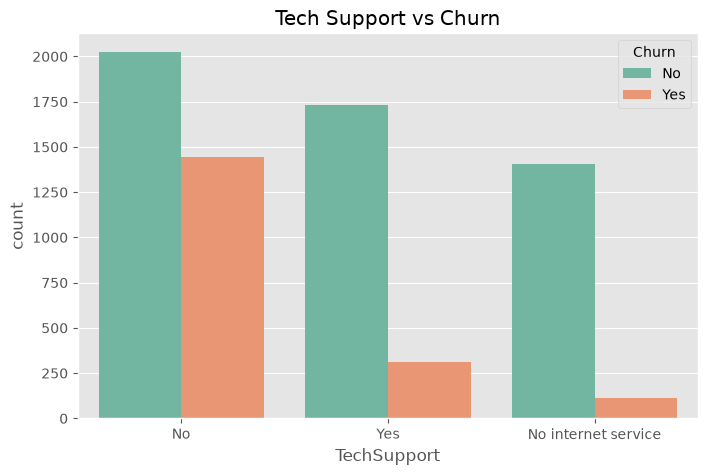

In [37]:
# ==============================================
# Tech Support vs Churn
# ==============================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Tech Support vs Churn")

plt.show()

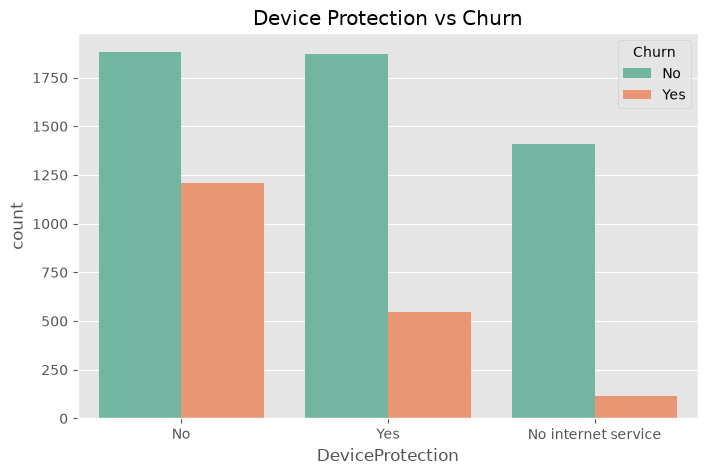

In [38]:
# ==============================================
# Device Protection vs Churn
# ==============================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="DeviceProtection", hue="Churn")

plt.title("Device Protection vs Churn")

plt.show()

### Observation

- Customers using fiber optic internet exhibit a higher churn rate than DSL users.
- Customers without online security are more likely to leave the company.
- Customers who do not subscribe to technical support show higher churn.
- Device protection services appear to improve customer retention.

## 6. Billing and Contract Analysis

This section examines how customer contracts, billing preferences,
and payment methods influence customer churn.

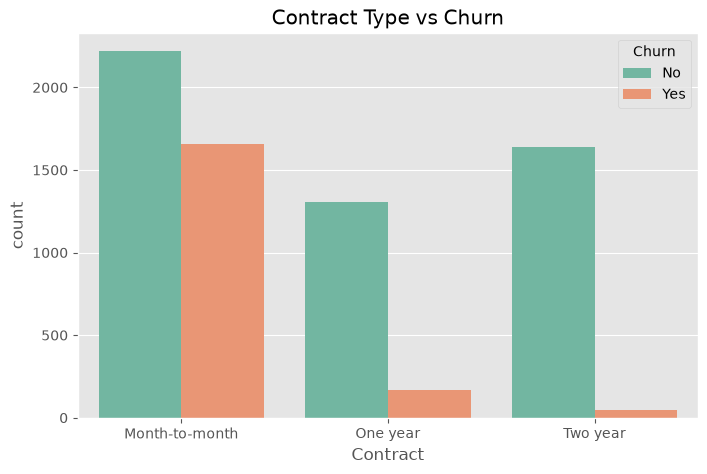

In [39]:
# ==============================================
# Contract vs Churn
# ==============================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Churn")

plt.show()

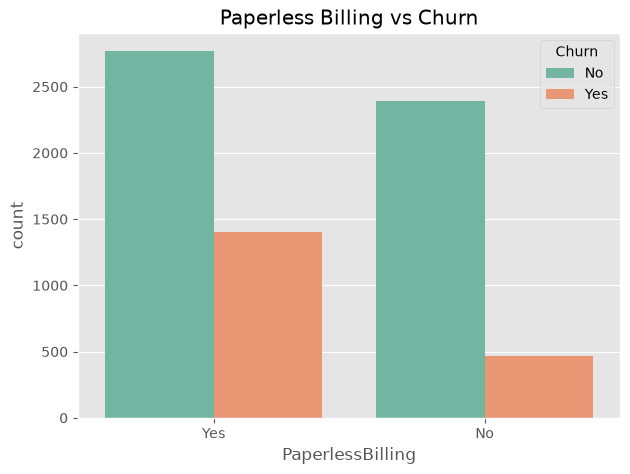

In [40]:
# ==============================================
# Paperless Billing vs Churn
# ==============================================

plt.figure(figsize=(7,5))

sns.countplot(data=df, x="PaperlessBilling", hue="Churn")

plt.title("Paperless Billing vs Churn")

plt.show()

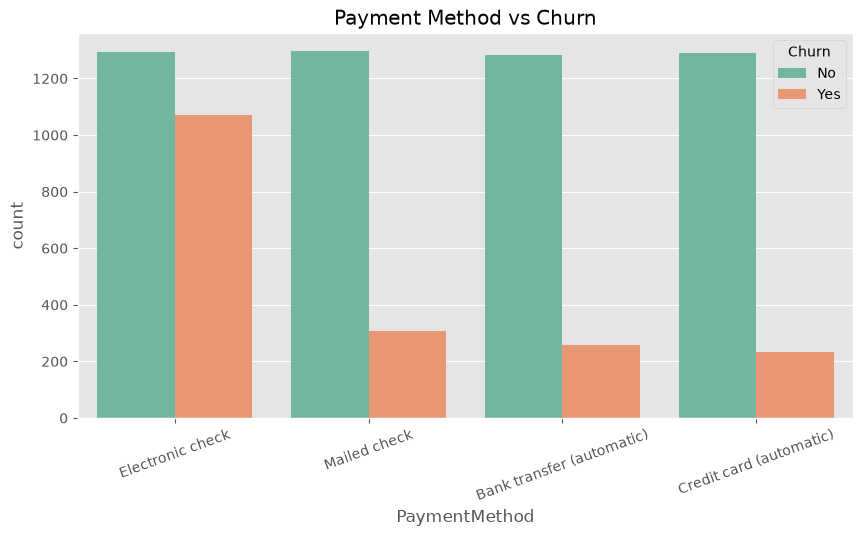

In [41]:
# ==============================================
# Payment Method vs Churn
# ==============================================

plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

### Observation

- Customers with month-to-month contracts have the highest churn rate.
- Customers with one-year and two-year contracts are significantly more likely to remain with the company.
- Paperless billing customers exhibit a relatively higher churn rate.
- Customers using electronic check payments tend to churn more frequently than customers using automatic payment methods.

## 7. Correlation Analysis

The numerical features are analyzed to understand their relationships and identify
potential correlations that may influence customer churn.

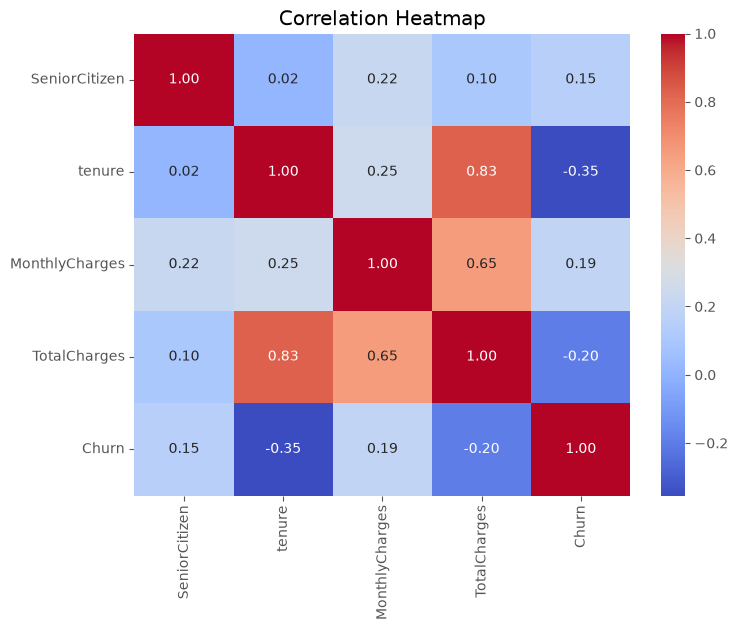

In [43]:
# ==============================================
# Correlation Heatmap
# ==============================================

# Create a copy for correlation
corr_df = df.copy()

# Convert target variable
corr_df["Churn"] = corr_df["Churn"].map({"No": 0, "Yes": 1})

# Select numerical columns
corr_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df[corr_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Customer tenure has a strong negative correlation with churn.
- Monthly charges show a positive relationship with churn.
- Total charges are negatively correlated with churn because long-term customers usually remain with the company.
- No severe multicollinearity exists among the numerical features.

## 8. Business Insights

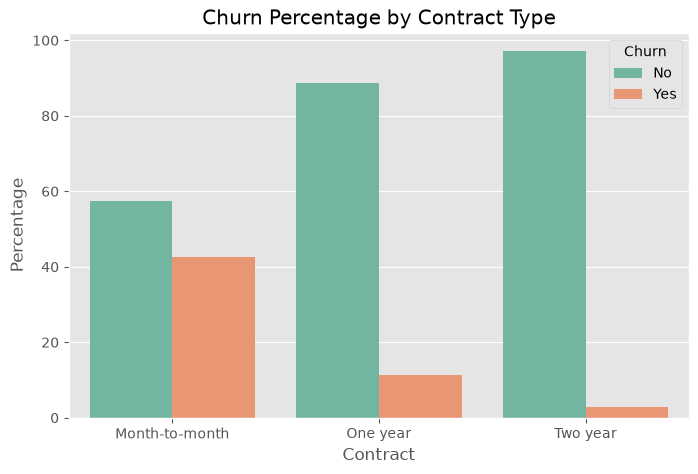

In [44]:
# ==============================================
# Churn Percentage by Contract Type
# ==============================================

contract_churn = (
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .rename("Percentage")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Percentage",
    hue="Churn"
)

plt.title("Churn Percentage by Contract Type")

plt.ylabel("Percentage")

plt.show()

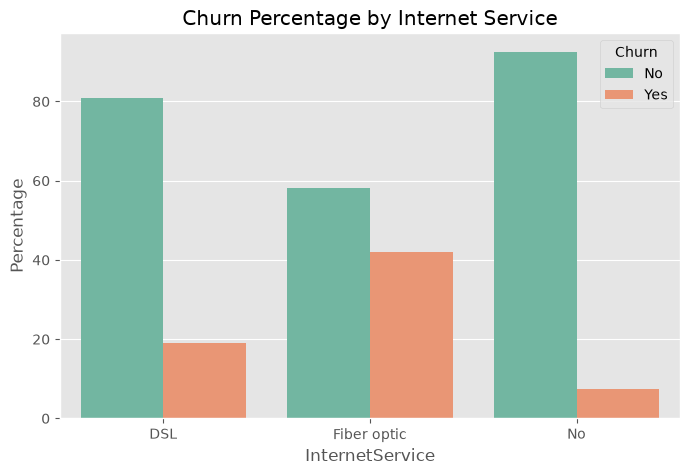

In [45]:
# ==============================================
# Churn Percentage by Internet Service
# ==============================================

internet_churn = (
    df.groupby("InternetService")["Churn"]
      .value_counts(normalize=True)
      .rename("Percentage")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Percentage",
    hue="Churn"
)

plt.title("Churn Percentage by Internet Service")

plt.ylabel("Percentage")

plt.show()

## 9. Final EDA Summary

The exploratory data analysis revealed several important business insights:

- Customer churn is influenced by both demographic and service-related factors.
- Customers with short tenure are significantly more likely to churn.
- Month-to-month contracts show the highest churn rates.
- Customers paying through electronic checks exhibit higher churn.
- Fiber optic internet customers demonstrate greater churn compared to DSL users.
- Customers without online security or technical support are more likely to leave.
- Long-term customers generally have higher lifetime value and better retention.
- The cleaned dataset is ready for feature engineering and machine learning model development.

In [46]:
# ==============================================
# Final Dataset Ready for Model Training
# ==============================================

print("Final Dataset Shape :", df.shape)

print("\nDataset is clean and ready for Model Training.")

Final Dataset Shape : (7032, 21)

Dataset is clean and ready for Model Training.


In [47]:
# ==============================================
# Save Clean Dataset
# ==============================================

df.to_csv("../data/customer_churn_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
